# Customer Segmentation Using Clustering Algorithms
### A Comparative Unsupervised Machine Learning Approach


# Project Overview

This project presents a complete customer segmentation workflow using Unsupervised Machine Learning techniques.

The objective is to identify groups of customers with similar purchasing behavior, demographic characteristics, and marketing responses to support data-driven business decisions.

The project covers the complete machine learning pipeline including:

- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Categorical Feature Encoding
- Feature Scaling
- Feature Selection
- Determining the Optimal Number of Clusters
- K-Means Clustering
- Agglomerative Clustering
- DBSCAN Clustering
- Clustering Model Comparison
- Cluster Visualization using PCA
- Cluster Profiling
- Business Insights and Recommendations

Finally, the clustering algorithms are compared using multiple evaluation metrics to select the most appropriate model for customer segmentation.

# Table of Contents

- Import Libraries
- Load Dataset
- Initial Data Exploration
- Data Cleaning
- Feature Engineering
- Feature Encoding
- Feature Scaling
- Feature Selection
- Elbow Method
- Silhouette Analysis
- K-Means Clustering
- Agglomerative Clustering
- DBSCAN
- Model Comparison
- Final Model Selection
- PCA Visualization
- Cluster Profile Analysis
- Cluster Visualizations
- Business Insights
- Conclusion

# Data Loading

In [1]:
# ==============================
# Import Required Libraries
# ==============================

import warnings
warnings.filterwarnings('ignore')

import kagglehub

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Display Settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Plot Style
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

In [2]:
# ==============================
# Download Dataset
# ==============================

dataset_path = kagglehub.dataset_download(
    "imakash3011/customer-personality-analysis"
)

print("Dataset Path:", dataset_path)

Using Colab cache for faster access to the 'customer-personality-analysis' dataset.
Dataset Path: /kaggle/input/customer-personality-analysis


# Exploratory Data Analysis (EDA)


In [3]:
# ==========================================================
# Load Dataset & Initial Exploration
# ==========================================================

import os

# Load Dataset
print("=" * 60)
print("Loading Dataset...")
print("=" * 60)

print("\nFiles in Dataset Directory:")
print(os.listdir(dataset_path))

df = pd.read_csv(
    os.path.join(dataset_path, "marketing_campaign.csv"),
    sep="\t"
)

print("\nDataset loaded successfully!")

# ==========================================================
# Basic Information
# ==========================================================

print("\n" + "=" * 60)
print("Dataset Shape")
print("=" * 60)

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

# ==========================================================
# Dataset Preview
# ==========================================================

print("\n" + "=" * 60)
print("First 5 Rows")
print("=" * 60)

display(df.head())

print("\n" + "=" * 60)
print("Last 5 Rows")
print("=" * 60)

display(df.tail())

# ==========================================================
# Dataset Information
# ==========================================================

print("\n" + "=" * 60)
print("Dataset Information")
print("=" * 60)

df.info()

# ==========================================================
# Statistical Summary
# ==========================================================

print("\n" + "=" * 60)
print("Numerical Features Summary")
print("=" * 60)

display(df.describe().T)

print("\n" + "=" * 60)
print("Categorical Features Summary")
print("=" * 60)

display(df.describe(include='object').T)

# ==========================================================
# Data Types
# ==========================================================

print("\n" + "=" * 60)
print("Data Types")
print("=" * 60)

display(df.dtypes)

# ==========================================================
# Missing Values
# ==========================================================

print("\n" + "=" * 60)
print("Missing Values")
print("=" * 60)

missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage (%)": (df.isnull().sum() / len(df) * 100).round(2)
})

display(
    missing_values[
        missing_values["Missing Values"] > 0
    ].sort_values(
        by="Missing Values",
        ascending=False
    )
)

# ==========================================================
# Duplicate Records
# ==========================================================

print("\n" + "=" * 60)
print("Duplicate Records")
print("=" * 60)

duplicates = df.duplicated().sum()

print(f"Duplicate Rows: {duplicates}")

Loading Dataset...

Files in Dataset Directory:
['marketing_campaign.csv']

Dataset loaded successfully!

Dataset Shape
Rows    : 2240
Columns : 29

First 5 Rows


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0



Last 5 Rows


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,43,182,42,118,247,2,9,3,4,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,0,30,0,0,8,7,8,2,5,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,48,217,32,12,24,1,2,3,13,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,30,214,80,30,61,2,6,5,10,3,0,0,0,0,0,0,3,11,0
2239,9405,1954,PhD,Married,52869.0,1,1,15-10-2012,40,84,3,61,2,1,21,3,3,1,4,7,0,0,0,0,0,0,3,11,1



Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases

...


Data Types


,0
ID,int64
Year_Birth,int64
Education,object
Marital_Status,object
Income,float64
Kidhome,int64
Teenhome,int64
Dt_Customer,object
Recency,int64
MntWines,int64



Missing Values


,Missing Values,Percentage (%)
Income,24,1.07



Duplicate Records
Duplicate Rows: 0


## Remove Duplicate Records

In [4]:
# ==========================================================
# Remove Duplicate Records
# ==========================================================

duplicates_before = df.duplicated().sum()

print("=" * 60)
print("Duplicate Records")
print("=" * 60)

print(f"Duplicate Rows Before Cleaning: {duplicates_before}")

# Remove duplicate rows
df.drop_duplicates(inplace=True)

duplicates_after = df.duplicated().sum()

print(f"Duplicate Rows After Cleaning : {duplicates_after}")

print(f"\nDataset Shape: {df.shape}")

Duplicate Records
Duplicate Rows Before Cleaning: 0
Duplicate Rows After Cleaning : 0

Dataset Shape: (2240, 29)


## Handle Missing Values

In [5]:
# ==========================================================
# Handle Missing Values
# ==========================================================

print("=" * 60)
print("Missing Values Before Handling")
print("=" * 60)

missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage (%)": (df.isnull().sum() / len(df) * 100).round(2)
})

display(
    missing_values[
        missing_values["Missing Values"] > 0
    ]
)

# Fill missing values in Income using Median
income_median = df["Income"].median()

df["Income"] = df["Income"].fillna(income_median)

print("\nIncome Median Used:", income_median)

print("\n" + "=" * 60)
print("Missing Values After Handling")
print("=" * 60)

display(
    pd.DataFrame({
        "Missing Values": df.isnull().sum(),
        "Percentage (%)": (df.isnull().sum() / len(df) * 100).round(2)
    })[
        lambda x: x["Missing Values"] > 0
    ]
)

Missing Values Before Handling


,Missing Values,Percentage (%)
Income,24,1.07



Income Median Used: 51381.5

Missing Values After Handling


,Missing Values,Percentage (%)


## Convert Data Types

In [6]:
# ==========================================================
# Convert Data Types
# ==========================================================

print("=" * 60)
print("Convert Data Types")
print("=" * 60)

# Convert customer enrollment date
df["Dt_Customer"] = pd.to_datetime(
    df["Dt_Customer"],
    format="%d-%m-%Y"
)

print("✓ Dt_Customer converted successfully.")

print("\nCurrent Data Types:")
display(df.dtypes)

Convert Data Types
✓ Dt_Customer converted successfully.

Current Data Types:


,0
ID,int64
Year_Birth,int64
Education,object
Marital_Status,object
Income,float64
Kidhome,int64
Teenhome,int64
Dt_Customer,datetime64[ns]
Recency,int64
MntWines,int64


## Data Consistency Checks

In [7]:
# ==========================================================
# Data Consistency Checks
# ==========================================================

print("=" * 60)
print("Constant Features Check")
print("=" * 60)

constant_features = [
    col for col in df.columns
    if df[col].nunique() == 1
]

print("Constant Features:")
print(constant_features)


# Remove constant features

df.drop(columns=constant_features, inplace=True)

print("\nDataset Shape After Removing Constant Features:")
print(df.shape)


# ==========================================================
# Categorical Values Check
# ==========================================================

print("\n" + "=" * 60)
print("Categorical Features Unique Values")
print("=" * 60)

for col in ["Education", "Marital_Status"]:
    print(f"\n{col}:")
    print(df[col].unique())

Constant Features Check
Constant Features:
['Z_CostContact', 'Z_Revenue']

Dataset Shape After Removing Constant Features:
(2240, 27)

Categorical Features Unique Values

Education:
['Graduation' 'PhD' 'Master' 'Basic' '2n Cycle']

Marital_Status:
['Single' 'Together' 'Married' 'Divorced' 'Widow' 'Alone' 'Absurd' 'YOLO']


# Handle Categorical Features


In [8]:
# ====================================================
# Inspect Unique Categories
# ====================================================

print("=" * 60)
print("Unique Categories Before Cleaning")
print("=" * 60)

for col in ["Education", "Marital_Status"]:
    print(f"\n{col}:")
    print(sorted(df[col].unique()))


Unique Categories Before Cleaning

Education:
['2n Cycle', 'Basic', 'Graduation', 'Master', 'PhD']

Marital_Status:
['Absurd', 'Alone', 'Divorced', 'Married', 'Single', 'Together', 'Widow', 'YOLO']


# Merge Rare Categories

In [9]:
# ==========================================================
# Merge Categorical Values
# ==========================================================

# Merge Education Categories
df["Education"] = df["Education"].replace({
    "Basic": "Undergraduate",
    "2n Cycle": "Master"
})

# Merge Marital Status Categories
df["Marital_Status"] = df["Marital_Status"].replace({
    "Alone": "Single",
    "Absurd": "Single",
    "YOLO": "Single",
    "Together": "Married"
})

print("=" * 60)
print("Categories After Cleaning")
print("=" * 60)

for col in ["Education", "Marital_Status"]:
    print(f"\n{col}:")
    print(sorted(df[col].unique()))

Categories After Cleaning

Education:
['Graduation', 'Master', 'PhD', 'Undergraduate']

Marital_Status:
['Divorced', 'Married', 'Single', 'Widow']


# Response Distribution

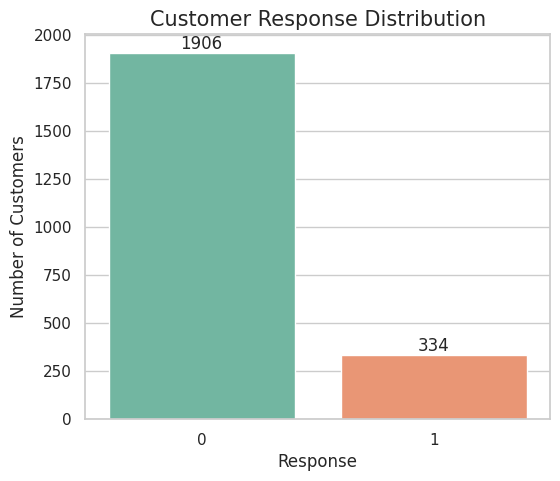

Response
0    85.09
1    14.91
Name: proportion, dtype: float64


In [10]:
# ==========================================================
# Target Variable Distribution
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

ax = sns.countplot(
    data=df,
    x="Response",
    palette="Set2"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Response Distribution", fontsize=15)
plt.xlabel("Response")
plt.ylabel("Number of Customers")

plt.show()

print(df["Response"].value_counts(normalize=True).mul(100).round(2))

# Customer Age Distribution

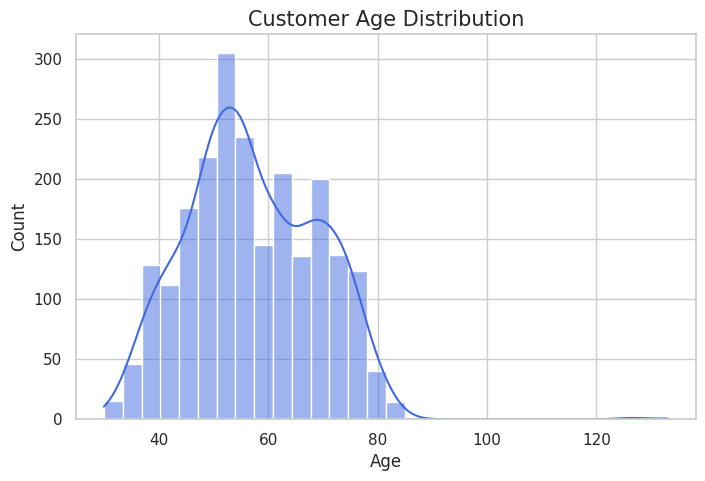

count    2240.000000
mean       57.194196
std        11.984069
min        30.000000
25%        49.000000
50%        56.000000
75%        67.000000
max       133.000000
Name: Age, dtype: float64


In [11]:
# ==========================================================
# Customer Age Analysis
# ==========================================================

# Create Customer Age
df["Age"] = 2026 - df["Year_Birth"]

plt.figure(figsize=(8,5))

sns.histplot(
    df["Age"],
    bins=30,
    kde=True,
    color="royalblue"
)

plt.title("Customer Age Distribution", fontsize=15)
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

print(df["Age"].describe())

## Handle Age Outliers


In [12]:
# ==========================================================
# Handle Age Outliers
# =========================================================

print("=" * 70)
print("Age Outliers Before Handling")
print("=" * 70)

print(df["Age"].describe())

# Keep customers between 18 and 100 years old
df = df[(df["Age"] >= 18) & (df["Age"] <= 100)]

print("\n" + "=" * 70)
print("Age Outliers After Handling")
print("=" * 70)

print(df["Age"].describe())
print(f"\nDataset Shape: {df.shape}")

Age Outliers Before Handling
count    2240.000000
mean       57.194196
std        11.984069
min        30.000000
25%        49.000000
50%        56.000000
75%        67.000000
max       133.000000
Name: Age, dtype: float64

Age Outliers After Handling
count    2237.000000
mean       57.098346
std        11.701917
min        30.000000
25%        49.000000
50%        56.000000
75%        67.000000
max        86.000000
Name: Age, dtype: float64

Dataset Shape: (2237, 28)


# Feature Engineering

## Create Customer Age

In [13]:
# ==========================================================
# Create Customer Age
# ==========================================================

# Calculate customer age
df["Age"] = 2026 - df["Year_Birth"]

print("=" * 60)
print("Customer Age Created Successfully")
print("=" * 60)

display(df[["Year_Birth", "Age"]].head())

print("\nAge Summary:")
display(df["Age"].describe())

Customer Age Created Successfully


,Year_Birth,Age
0,1957,69
1,1954,72
2,1965,61
3,1984,42
4,1981,45



Age Summary:


,Age
count,2237.000000
mean,57.098346
std,11.701917
min,30.000000
25%,49.000000
50%,56.000000
75%,67.000000
max,86.000000


## Create Customer Seniority

In [14]:
# ==========================================================
# Create Customer Seniority
# ==========================================================

# Define the reference date (latest customer enrollment date)
reference_date = df["Dt_Customer"].max()

# Calculate customer seniority in days
df["Customer_Seniority"] = (
    reference_date - df["Dt_Customer"]
).dt.days

print("=" * 60)
print("Customer Seniority Created Successfully")
print("=" * 60)

display(df[["Dt_Customer", "Customer_Seniority"]].head())

print("\nCustomer Seniority Summary:")
display(df["Customer_Seniority"].describe())

Customer Seniority Created Successfully


,Dt_Customer,Customer_Seniority
0,2012-09-04,663
1,2014-03-08,113
2,2013-08-21,312
3,2014-02-10,139
4,2014-01-19,161



Customer Seniority Summary:


,Customer_Seniority
count,2237.000000
mean,353.790344
std,202.137961
min,0.000000
25%,181.000000
50%,356.000000
75%,529.000000
max,699.000000


## Create Total Spending

In [15]:
# ==========================================================
# Create Total Spending
# ==========================================================

# Calculate the total amount spent by each customer
df["Total_Spending"] = (
    df["MntWines"] +
    df["MntFruits"] +
    df["MntMeatProducts"] +
    df["MntFishProducts"] +
    df["MntSweetProducts"] +
    df["MntGoldProds"]
)

print("=" * 60)
print("Total Spending Created Successfully")
print("=" * 60)

display(
    df[
        [
            "MntWines",
            "MntFruits",
            "MntMeatProducts",
            "MntFishProducts",
            "MntSweetProducts",
            "MntGoldProds",
            "Total_Spending"
        ]
    ].head()
)

print("\nSummary Statistics:")
print(df["Total_Spending"].describe())

Total Spending Created Successfully


,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,Total_Spending
0,635,88,546,172,88,88,1617
1,11,1,6,2,1,6,27
2,426,49,127,111,21,42,776
3,11,4,20,10,3,5,53
4,173,43,118,46,27,15,422



Summary Statistics:
count    2237.000000
mean      605.743406
std       601.840466
min         5.000000
25%        69.000000
50%       396.000000
75%      1045.000000
max      2525.000000
Name: Total_Spending, dtype: float64


## Create Total Purchases


In [16]:
# ==========================================================
# Create Total Purchases
# ==========================================================

# Calculate the total number of purchases made by each customer
df["Total_Purchases"] = (
    df["NumDealsPurchases"] +
    df["NumWebPurchases"] +
    df["NumCatalogPurchases"] +
    df["NumStorePurchases"]
)

print("=" * 60)
print("Total Purchases Created Successfully")
print("=" * 60)

display(
    df[
        [
            "NumDealsPurchases",
            "NumWebPurchases",
            "NumCatalogPurchases",
            "NumStorePurchases",
            "Total_Purchases"
        ]
    ].head()
)

print("\nSummary Statistics:")
print(df["Total_Purchases"].describe())

Total Purchases Created Successfully


,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,Total_Purchases
0,3,8,10,4,25
1,2,1,1,2,6
2,1,8,2,10,21
3,2,2,0,4,8
4,5,5,3,6,19



Summary Statistics:
count    2237.000000
mean       14.870809
std         7.676593
min         0.000000
25%         8.000000
50%        15.000000
75%        21.000000
max        44.000000
Name: Total_Purchases, dtype: float64


## Create Family Features


In [17]:
# ==========================================================
# Create Family Features
# ==========================================================

# Total number of children
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

# Number of family members
df["Family_Size"] = df["Total_Children"] + df["Marital_Status"].replace({
    "Single": 1,
    "Divorced": 1,
    "Widow": 1,
    "Married": 2
})

# Living status
df["Living_With"] = df["Marital_Status"].replace({
    "Single": "Alone",
    "Divorced": "Alone",
    "Widow": "Alone",
    "Married": "Partner"
})

print("=" * 60)
print("Family Features Created Successfully")
print("=" * 60)

display(
    df[
        [
            "Kidhome",
            "Teenhome",
            "Marital_Status",
            "Total_Children",
            "Family_Size",
            "Living_With"
        ]
    ].head()
)

print("\nSummary Statistics:")
display(df[["Total_Children", "Family_Size"]].describe())

Family Features Created Successfully


,Kidhome,Teenhome,Marital_Status,Total_Children,Family_Size,Living_With
0,0,0,Single,0,1,Alone
1,1,1,Single,2,3,Alone
2,0,0,Married,0,2,Partner
3,1,0,Married,1,3,Partner
4,1,0,Married,1,3,Partner



Summary Statistics:


,Total_Children,Family_Size
count,2237.000000,2237.000000
mean,0.950827,2.595887
std,0.752037,0.907305
min,0.000000,1.000000
25%,0.000000,2.000000
50%,1.000000,3.000000
75%,1.000000,3.000000
max,3.000000,5.000000


## Create Total Accepted Campaigns


In [18]:
# ==========================================================
# Create Total Accepted Campaigns
# ==========================================================

# Calculate the total number of accepted marketing campaigns
df["Total_Accepted_Campaigns"] = (
    df["AcceptedCmp1"] +
    df["AcceptedCmp2"] +
    df["AcceptedCmp3"] +
    df["AcceptedCmp4"] +
    df["AcceptedCmp5"] +
    df["Response"]
)

print("=" * 60)
print("Total Accepted Campaigns Created Successfully")
print("=" * 60)

display(
    df[
        [
            "AcceptedCmp1",
            "AcceptedCmp2",
            "AcceptedCmp3",
            "AcceptedCmp4",
            "AcceptedCmp5",
            "Response",
            "Total_Accepted_Campaigns"
        ]
    ].head()
)

print("\nSummary Statistics:")
display(df["Total_Accepted_Campaigns"].describe())


Total Accepted Campaigns Created Successfully


,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response,Total_Accepted_Campaigns
0,0,0,0,0,0,1,1
1,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0



Summary Statistics:


,Total_Accepted_Campaigns
count,2237.000000
mean,0.447027
std,0.890964
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,5.000000


## Customer Spending Features

In [19]:
# ==========================================================
# Create Customer Spending Features
# ==========================================================

# Total spending across all product categories
spending_columns = [
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]

df["Total_Spending"] = df[spending_columns].sum(axis=1)

# Average spending per product category
df["Average_Spending"] = df[spending_columns].mean(axis=1)

# Total number of purchases
purchase_columns = [
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases"
]

df["Total_Purchases"] = df[purchase_columns].sum(axis=1)

print("=" * 70)
print("Customer Spending Features")
print("=" * 70)

display(
    df[
        spending_columns +
        ["Total_Spending", "Average_Spending", "Total_Purchases"]
    ].head()
)

print("\nSummary Statistics:\n")
display(
    df[
        ["Total_Spending",
         "Average_Spending",
         "Total_Purchases"]
    ].describe().round(2)
)

Customer Spending Features


,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,Total_Spending,Average_Spending,Total_Purchases
0,635,88,546,172,88,88,1617,269.500000,22
1,11,1,6,2,1,6,27,4.500000,4
2,426,49,127,111,21,42,776,129.333333,20
3,11,4,20,10,3,5,53,8.833333,6
4,173,43,118,46,27,15,422,70.333333,14



Summary Statistics:



,Total_Spending,Average_Spending,Total_Purchases
count,2237.00,2237.00,2237.00
mean,605.74,100.96,12.54
std,601.84,100.31,7.21
min,5.00,0.83,0.00
25%,69.00,11.50,6.00
50%,396.00,66.00,12.00
75%,1045.00,174.17,18.00
max,2525.00,420.83,32.00


## Categorical Feature Encoding

In [20]:
# ==========================================================
# Encode Categorical Features
# ==========================================================

from sklearn.preprocessing import LabelEncoder

# Create a copy after completing Feature Engineering
df_encoded = df.copy()

# Select categorical columns
categorical_columns = df_encoded.select_dtypes(include="object").columns

print("=" * 70)
print("Categorical Columns")
print("=" * 70)
print(categorical_columns.tolist())

# Apply Label Encoding
label_encoders = {}

for col in categorical_columns:
    encoder = LabelEncoder()
    df_encoded[col] = encoder.fit_transform(df_encoded[col])
    label_encoders[col] = encoder

print("\nEncoding Completed Successfully.")

print("\nData Types:")
display(df_encoded.dtypes)

Categorical Columns
['Education', 'Marital_Status', 'Living_With']

Encoding Completed Successfully.

Data Types:


,0
ID,int64
Year_Birth,int64
Education,int64
Marital_Status,int64
Income,float64
Kidhome,int64
Teenhome,int64
Dt_Customer,datetime64[ns]
Recency,int64
MntWines,int64


## Data Scaling



In [21]:
# ==========================================================
# Scale Features
# ==========================================================

from sklearn.preprocessing import StandardScaler

# Create a copy for scaling
df_scaled = df_encoded.copy()

# Remove unnecessary columns
columns_to_drop = [
    "ID",
    "Dt_Customer"
]

existing_columns = [
    col for col in columns_to_drop
    if col in df_scaled.columns
]

df_scaled.drop(columns=existing_columns, inplace=True)

# Scale all remaining features
scaler = StandardScaler()

df_scaled[:] = scaler.fit_transform(df_scaled)

print("=" * 70)
print("Scaling Completed Successfully")
print("=" * 70)

display(df_scaled.head())

Scaling Completed Successfully


,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,Customer_Seniority,Total_Spending,Total_Purchases,Total_Children,Family_Size,Living_With,Total_Accepted_Campaigns,Average_Spending
0,-1.017296,-0.873152,1.253808,0.236068,-0.825388,-0.930227,0.307272,0.983671,1.554623,1.680253,2.461700,1.475877,0.846061,0.348371,1.408080,2.510435,-0.552077,0.692882,-0.280343,-0.284036,-0.279414,-0.262299,-0.11659,-0.09498,2.386966,1.017296,1.530038,1.680649,1.312543,-1.264618,-1.759324,-1.348103,0.620785,1.680649
1,-1.273722,-0.873152,1.253808,-0.234982,1.032151,0.906417,-0.383584,-0.870717,-0.636422,-0.713250,-0.650275,-0.631440,-0.729569,-0.169096,-1.110957,-0.568802,-1.167421,-0.131574,-0.280343,-0.284036,-0.279414,-0.262299,-0.11659,-0.09498,-0.418942,1.273722,-1.191484,-0.961838,-1.185961,1.395420,0.445498,-1.348103,-0.501847,-0.961838
2,-0.333495,-0.873152,-0.280529,0.774257,-0.825388,-0.930227,-0.798098,0.362570,0.572430,-0.176928,1.345050,-0.147000,-0.037829,-0.686563,1.408080,-0.226664,1.293956,-0.543802,-0.280343,-0.284036,-0.279414,-0.262299,-0.11659,-0.09498,-0.418942,0.333495,-0.206788,0.282956,1.034932,-1.264618,-0.656913,0.741783,-0.501847,0.282956
3,1.290534,-0.873152,-0.280529,-1.021717,1.032151,-0.930227,-0.798098,-0.870717,-0.560868,-0.651196,-0.503829,-0.582996,-0.748784,-0.169096,-0.751094,-0.910939,-0.552077,0.280654,-0.280343,-0.284036,-0.279414,-0.262299,-0.11659,-0.09498,-0.418942,-1.290534,-1.062830,-0.918627,-0.908350,0.065401,0.445498,0.741783,-0.501847,-0.918627
4,1.034108,1.420731,-0.280529,0.242259,1.032151,-0.930227,1.550812,-0.389289,0.421324,-0.216820,0.155177,-0.001667,-0.556634,1.383304,0.328493,0.115473,0.063267,-0.131574,-0.280343,-0.284036,-0.279414,-0.262299,-0.11659,-0.09498,-0.418942,-1.034108,-0.953970,-0.305371,0.202097,0.065401,0.445498,0.741783,-0.501847,-0.305371


## Feature Selection


In [22]:
# ==========================================================
# Prepare Feature Matrix
# ==========================================================

features = df_scaled.copy()

print("=" * 70)
print("Feature Matrix Ready")
print("=" * 70)

print(f"Shape : {features.shape}")

print("\nColumns:\n")
print(features.columns.tolist())

Feature Matrix Ready
Shape : (2237, 34)

Columns:

['Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Response', 'Age', 'Customer_Seniority', 'Total_Spending', 'Total_Purchases', 'Total_Children', 'Family_Size', 'Living_With', 'Total_Accepted_Campaigns', 'Average_Spending']


## Find the Optimal Number of Clusters

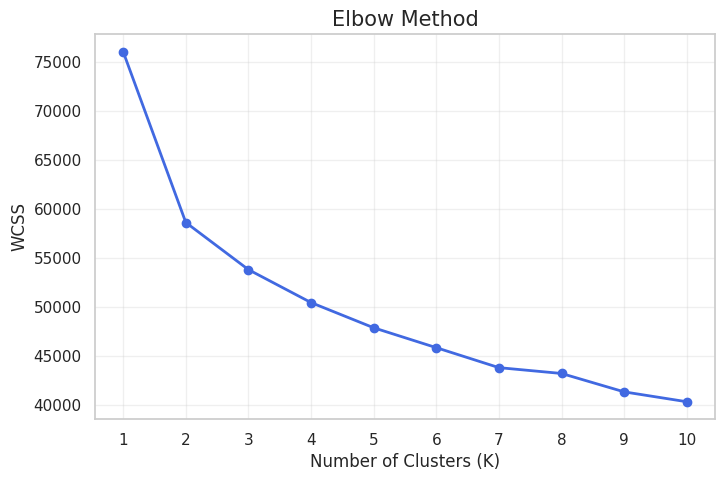

In [23]:
# ==========================================================
# Elbow Method
# ==========================================================

from sklearn.cluster import KMeans

# Store WCSS values
wcss = []

# Train K-Means with different numbers of clusters
for k in range(1, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(features)
    wcss.append(model.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o',
    linewidth=2,
    color='royalblue'
)

plt.title("Elbow Method", fontsize=15)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

plt.xticks(range(1,11))
plt.grid(alpha=0.3)

plt.show()

## Silhouette Score

Silhouette Scores
K = 2 --> 0.2465
K = 3 --> 0.1671
K = 4 --> 0.1659
K = 5 --> 0.1117
K = 6 --> 0.1164
K = 7 --> 0.1211
K = 8 --> 0.1181
K = 9 --> 0.1144
K = 10 --> 0.1149


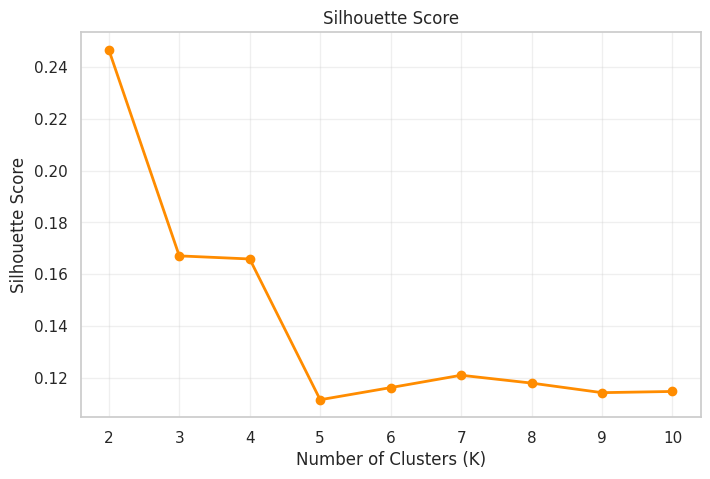

In [24]:
# ==========================================================
# Evaluate the Optimal Number of Clusters
# ==========================================================

from sklearn.metrics import silhouette_score

scores = []

for k in range(2, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(features)

    score = silhouette_score(features, labels)
    scores.append(score)

print("=" * 70)
print("Silhouette Scores")
print("=" * 70)

for k, score in zip(range(2, 11), scores):
    print(f"K = {k} --> {score:.4f}")

# Plot
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    scores,
    marker="o",
    linewidth=2,
    color="darkorange"
)

plt.title("Silhouette Score")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")

plt.xticks(range(2,11))
plt.grid(alpha=0.3)

plt.show()

## Train K-Means Model

In [25]:
# ===================================================
# Train the K-Means Model
# ===================================================

# Train the model
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# Fit model
cluster_labels = kmeans.fit_predict(features)

# Save cluster labels
features["Cluster"] = cluster_labels

# Add labels to original dataframe
clustered_df = df.copy()
clustered_df["Cluster"] = cluster_labels

print("=" * 70)
print("K-Means Model Trained Successfully")
print("=" * 70)

print("\nCluster Distribution:\n")
print(clustered_df["Cluster"].value_counts().sort_index())

display(clustered_df.head())

K-Means Model Trained Successfully

Cluster Distribution:

Cluster
0    1071
1     511
2     655
Name: count, dtype: int64


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,Customer_Seniority,Total_Spending,Total_Purchases,Total_Children,Family_Size,Living_With,Total_Accepted_Campaigns,Average_Spending,Cluster
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,1,69,663,1617,22,0,1,Alone,1,269.500000,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,0,72,113,27,4,2,3,Alone,0,4.500000,0
2,4141,1965,Graduation,Married,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,0,61,312,776,20,0,2,Partner,0,129.333333,2
3,6182,1984,Graduation,Married,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,0,42,139,53,6,1,3,Partner,0,8.833333,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,0,45,161,422,14,1,3,Partner,0,70.333333,0


# Agglomerative Clustering

In [26]:
# ==========================================================
# Agglomerative Clustering
# ==========================================================

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

agglomerative = AgglomerativeClustering(
    n_clusters=3
)

agg_labels = agglomerative.fit_predict(features.drop(columns=["Cluster"]))

agg_silhouette = silhouette_score(
    features.drop(columns=["Cluster"]),
    agg_labels
)

agg_calinski = calinski_harabasz_score(
    features.drop(columns=["Cluster"]),
    agg_labels
)

agg_davies = davies_bouldin_score(
    features.drop(columns=["Cluster"]),
    agg_labels
)

print("="*70)
print("Agglomerative Clustering Results")
print("="*70)

print(f"Silhouette Score : {agg_silhouette:.4f}")
print(f"Calinski-Harabasz Index : {agg_calinski:.2f}")
print(f"Davies-Bouldin Index : {agg_davies:.4f}")

Agglomerative Clustering Results
Silhouette Score : 0.1962
Calinski-Harabasz Index : 382.98
Davies-Bouldin Index : 2.1980


# DBSCAN Clustering


In [27]:
# ==========================================================
# DBSCAN Clustering
# ==========================================================

from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=2.2,
    min_samples=8
)

db_labels = dbscan.fit_predict(
    features.drop(columns=["Cluster"])
)

valid_mask = db_labels != -1

if len(set(db_labels[valid_mask])) > 1:

    db_silhouette = silhouette_score(
        features.drop(columns=["Cluster"]).iloc[valid_mask],
        db_labels[valid_mask]
    )

    db_calinski = calinski_harabasz_score(
        features.drop(columns=["Cluster"]).iloc[valid_mask],
        db_labels[valid_mask]
    )

    db_davies = davies_bouldin_score(
        features.drop(columns=["Cluster"]).iloc[valid_mask],
        db_labels[valid_mask]
    )

    print("="*70)
    print("DBSCAN Results")
    print("="*70)

    print(f"Silhouette Score : {db_silhouette:.4f}")
    print(f"Calinski-Harabasz Index : {db_calinski:.2f}")
    print(f"Davies-Bouldin Index : {db_davies:.4f}")

else:
    print("DBSCAN could not identify more than one valid cluster.")


DBSCAN Results
Silhouette Score : 0.2298
Calinski-Harabasz Index : 78.72
Davies-Bouldin Index : 1.4244


# Clustering Model Comparison

In [28]:
# ==========================================================
# Clustering Model Comparison
# ==========================================================

from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

X = features.drop(columns=["Cluster"])

# K-Means Metrics
kmeans_labels = features["Cluster"]

kmeans_silhouette = silhouette_score(X, kmeans_labels)
kmeans_calinski = calinski_harabasz_score(X, kmeans_labels)
kmeans_davies = davies_bouldin_score(X, kmeans_labels)

# Comparison Table
comparison = pd.DataFrame({
    "Algorithm": [
        "K-Means",
        "Agglomerative",
        "DBSCAN"
    ],
    "Silhouette Score": [
        kmeans_silhouette,
        agg_silhouette,
        db_silhouette if "db_silhouette" in locals() else np.nan
    ],
    "Calinski-Harabasz": [
        kmeans_calinski,
        agg_calinski,
        db_calinski if "db_calinski" in locals() else np.nan
    ],
    "Davies-Bouldin": [
        kmeans_davies,
        agg_davies,
        db_davies if "db_davies" in locals() else np.nan
    ]
})

comparison = comparison.round(4)

print("=" * 70)
print("Clustering Model Comparison")
print("=" * 70)

display(comparison)

Clustering Model Comparison


,Algorithm,Silhouette Score,Calinski-Harabasz,Davies-Bouldin
0,K-Means,0.1671,460.9869,2.1832
1,Agglomerative,0.1962,382.9804,2.1980
2,DBSCAN,0.2298,78.7243,1.4244


# Model Comparison Visualization

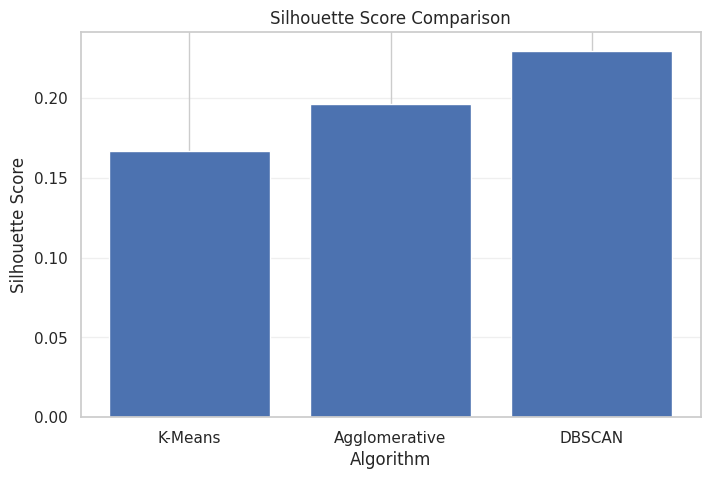

In [29]:
# ==========================================================
# Model Comparison Visualization
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    comparison["Algorithm"],
    comparison["Silhouette Score"]
)

plt.title("Silhouette Score Comparison")
plt.xlabel("Algorithm")
plt.ylabel("Silhouette Score")

plt.grid(axis="y", alpha=0.3)

plt.show()

# Model Selection Summary


In [30]:
# ==========================================================
# Model Selection Summary
# ==========================================================

best_model = comparison.sort_values(
    by="Silhouette Score",
    ascending=False
).iloc[0]

print("=" * 70)
print("Final Model Selection")
print("=" * 70)

print(f"Selected Algorithm : {best_model['Algorithm']}")
print(f"Silhouette Score : {best_model['Silhouette Score']:.4f}")

print("\nReason for Selection:")
print("- Highest Silhouette Score.")
print("- Better separation between customer groups.")
print("- More suitable for customer segmentation.")

Final Model Selection
Selected Algorithm : DBSCAN
Silhouette Score : 0.2298

Reason for Selection:
- Highest Silhouette Score.
- Better separation between customer groups.
- More suitable for customer segmentation.


# PCA Visualization

PCA Explained Variance
PC1 : 29.38%
PC2 : 9.19%
Total : 38.58%


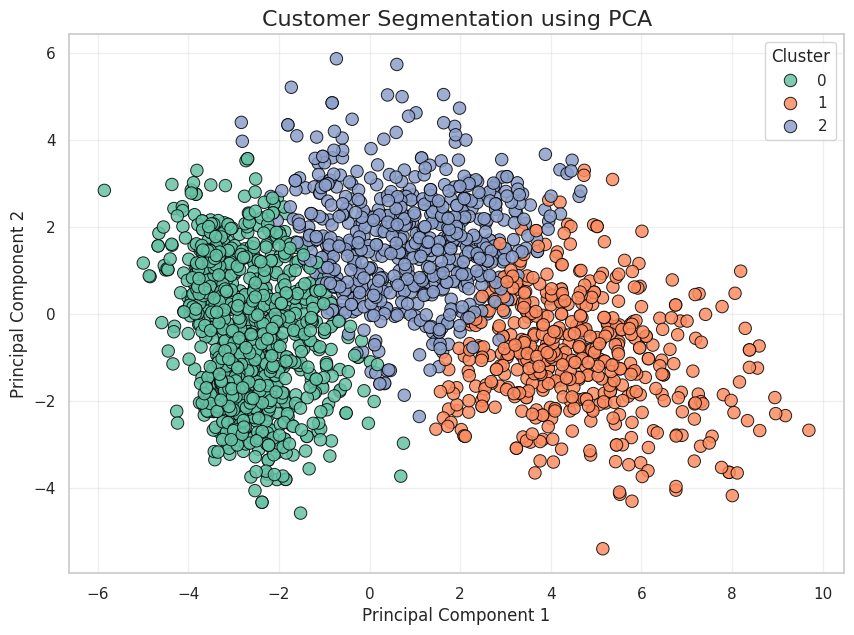

In [31]:
# ==========================================================
# PCA Visualization
# ==========================================================

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Features without cluster labels
X = features.drop(columns=["Cluster"])

# PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

# Explained variance
explained_variance = pca.explained_variance_ratio_

print("=" * 70)
print("PCA Explained Variance")
print("=" * 70)
print(f"PC1 : {explained_variance[0]:.2%}")
print(f"PC2 : {explained_variance[1]:.2%}")
print(f"Total : {explained_variance.sum():.2%}")

# DataFrame
pca_df = pd.DataFrame({
    "PC1": X_pca[:,0],
    "PC2": X_pca[:,1],
    "Cluster": features["Cluster"]
})

# Plot
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2",
    s=80,
    edgecolor="black",
    alpha=0.85
)

plt.title("Customer Segmentation using PCA", fontsize=16)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.grid(alpha=0.3)

plt.show()

# Cluster Profile Heatmap


Cluster Profile


,Age,Income,Total_Spending,Average_Spending,Total_Purchases,Customer_Seniority,Total_Accepted_Campaigns
Cluster,,,,,,,
0,54.47,35629.55,103.72,17.29,6.04,323.18,0.18
1,57.00,78198.80,1440.05,240.01,19.43,359.82,1.18
2,61.48,59105.15,775.72,129.29,17.82,399.14,0.32


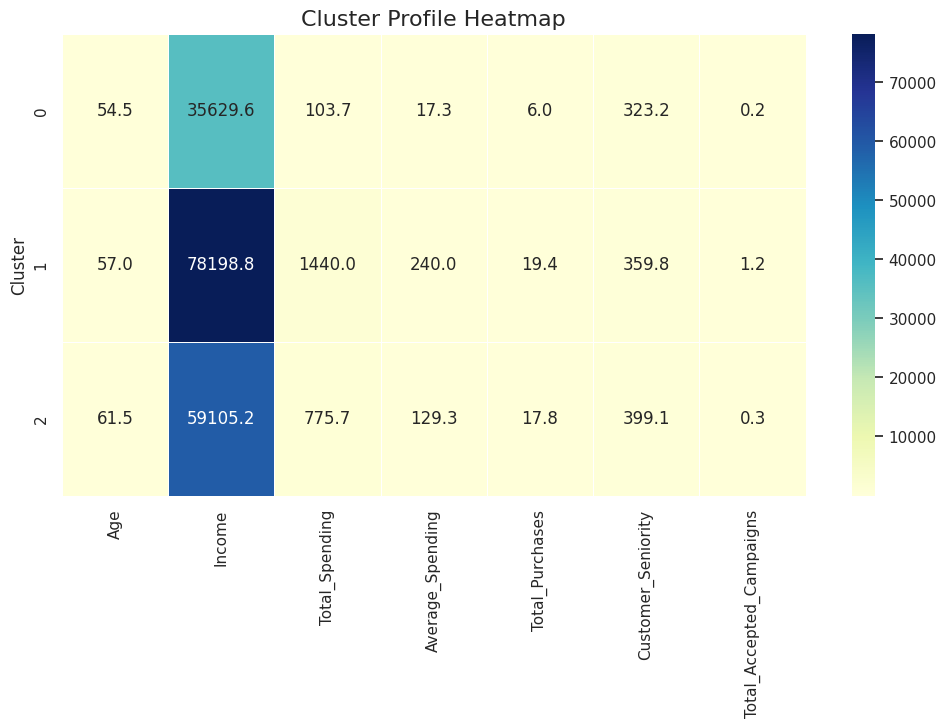

In [32]:
# ==========================================================
# Cluster Profile Heatmap
# ==========================================================

important_features = [
    "Age",
    "Income",
    "Total_Spending",
    "Average_Spending",
    "Total_Purchases",
    "Customer_Seniority",
    "Total_Accepted_Campaigns"
]

cluster_profile = (
    clustered_df
    .groupby("Cluster")[important_features]
    .mean()
    .round(2)
)

print("="*70)
print("Cluster Profile")
print("="*70)

display(cluster_profile)

plt.figure(figsize=(12,6))

sns.heatmap(
    cluster_profile,
    annot=True,
    cmap="YlGnBu",
    fmt=".1f",
    linewidths=.5
)

plt.title("Cluster Profile Heatmap", fontsize=16)

plt.show()

# Cluster Distribution


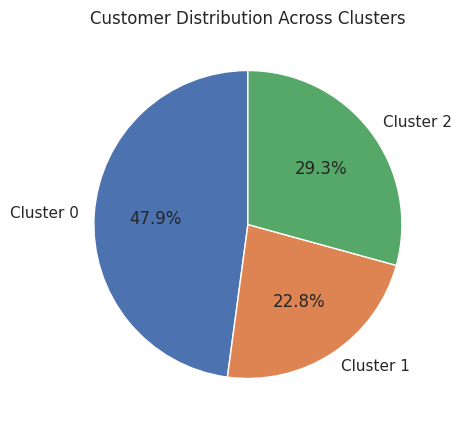

In [33]:
# ==========================================================
# Cluster Distribution
# ==========================================================

cluster_counts = clustered_df["Cluster"].value_counts().sort_index()

plt.figure(figsize=(7,5))

plt.pie(
    cluster_counts,
    labels=[f"Cluster {i}" for i in cluster_counts.index],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Customer Distribution Across Clusters")

plt.show()

# Customer Distribution Across Clusters

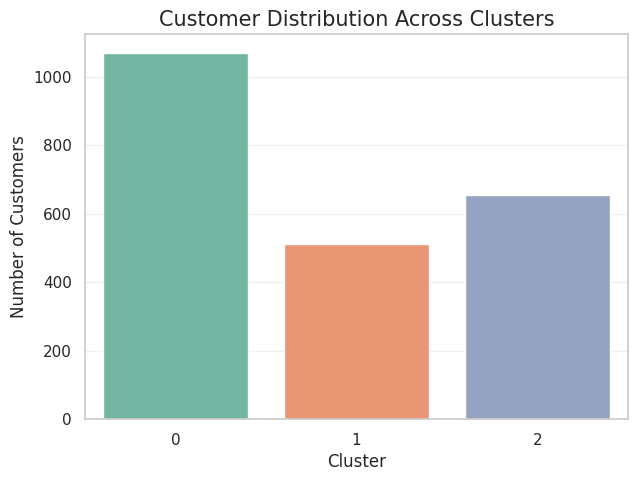

In [34]:
# ==========================================================
# Customer Distribution Across Clusters
# ==========================================================

plt.figure(figsize=(7,5))

sns.countplot(
    x="Cluster",
    data=clustered_df,
    palette="Set2"
)

plt.title("Customer Distribution Across Clusters", fontsize=15)
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.grid(axis="y", alpha=0.3)

plt.show()

# Spending Distribution by Cluster

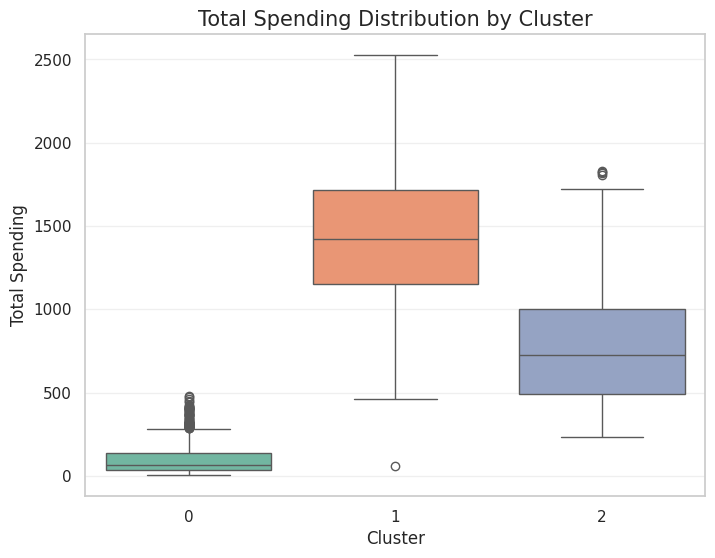

In [35]:
# ==========================================================
# Spending Distribution by Cluster
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.boxplot(
    data=clustered_df,
    x="Cluster",
    y="Total_Spending",
    palette="Set2"
)

plt.title("Total Spending Distribution by Cluster", fontsize=15)
plt.xlabel("Cluster")
plt.ylabel("Total Spending")

plt.grid(axis="y", alpha=0.3)

plt.show()

# Income Distribution by Cluster

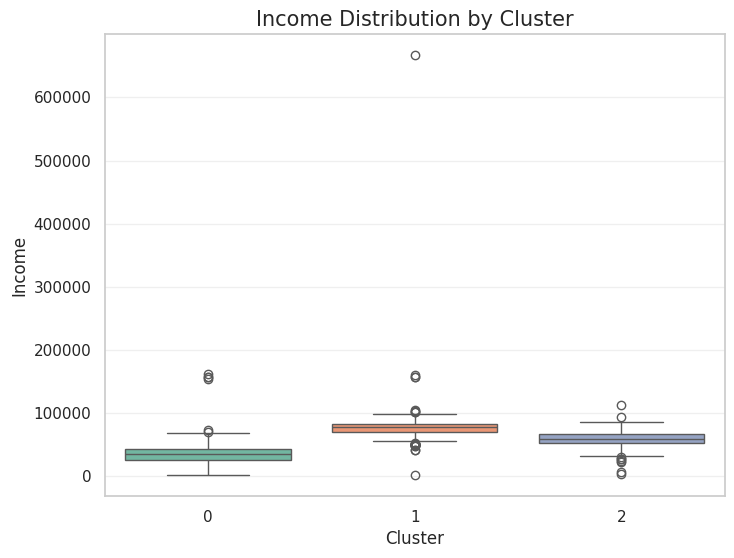

In [36]:
# ==========================================================
# Income Distribution by Cluster
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.boxplot(
    data=clustered_df,
    x="Cluster",
    y="Income",
    palette="Set2"
)

plt.title("Income Distribution by Cluster", fontsize=15)
plt.xlabel("Cluster")
plt.ylabel("Income")

plt.grid(axis="y", alpha=0.3)

plt.show()

# Age Distribution by Cluster

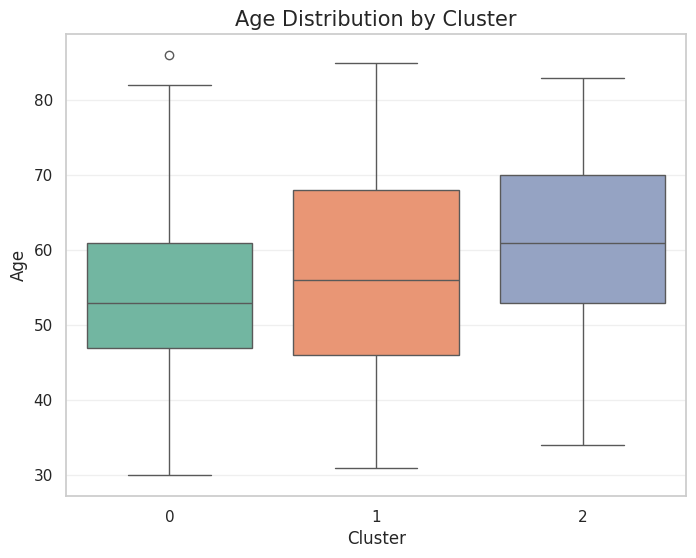

In [37]:
# ==========================================================
# Age Distribution by Cluster
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.boxplot(
    data=clustered_df,
    x="Cluster",
    y="Age",
    palette="Set2"
)

plt.title("Age Distribution by Cluster", fontsize=15)
plt.xlabel("Cluster")
plt.ylabel("Age")

plt.grid(axis="y", alpha=0.3)

plt.show()

# Customer Seniority by Cluster

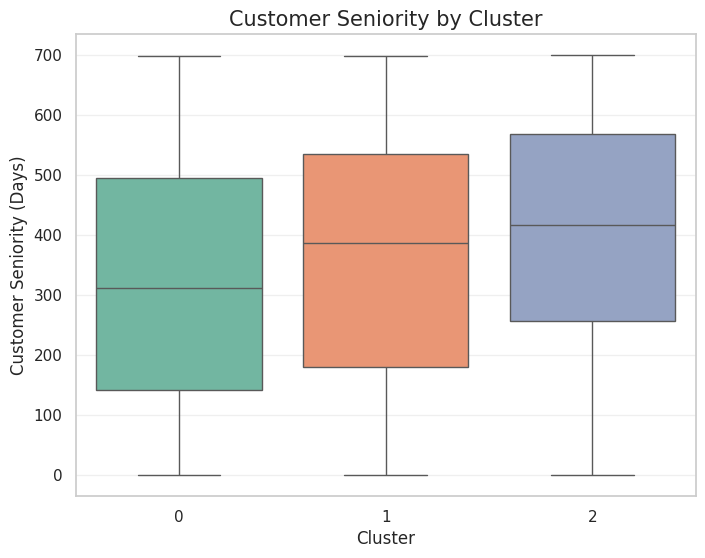

In [38]:
# ==========================================================
# Customer Seniority by Cluster
# ==========================================================

plt.figure(figsize=(8,6))

sns.boxplot(
    data=clustered_df,
    x="Cluster",
    y="Customer_Seniority",
    palette="Set2"
)

plt.title("Customer Seniority by Cluster", fontsize=15)
plt.xlabel("Cluster")
plt.ylabel("Customer Seniority (Days)")

plt.grid(axis="y", alpha=0.3)

plt.show()

# Customer Segment Comparison



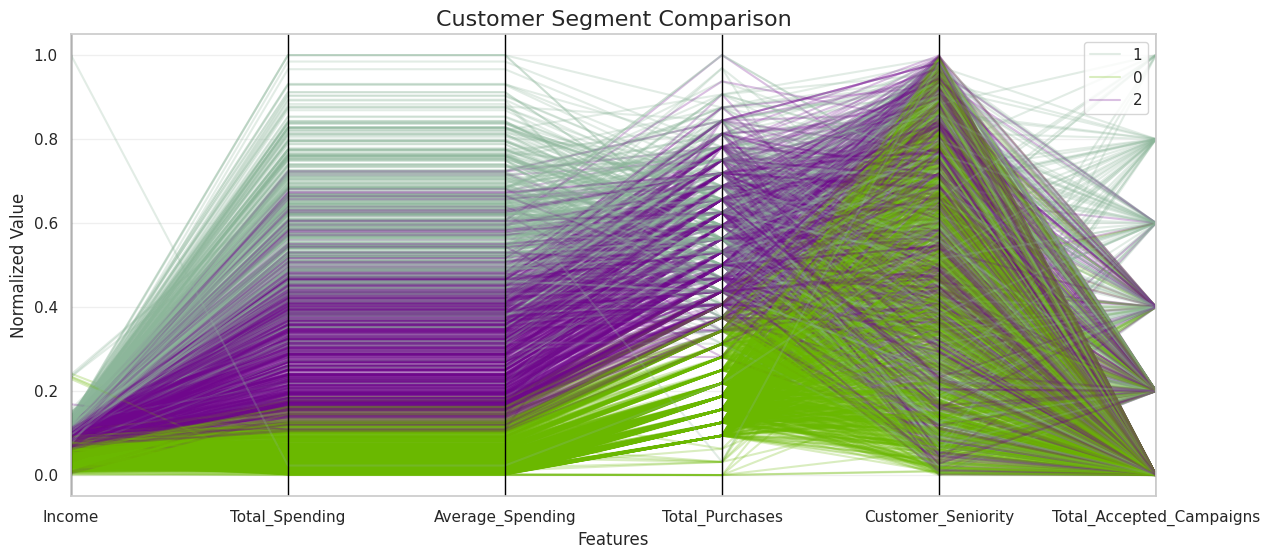

In [39]:
# ==========================================================
# Customer Segment Comparison (Parallel Coordinates Plot)
# ==========================================================

from pandas.plotting import parallel_coordinates
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

selected_features = [
    "Income",
    "Total_Spending",
    "Average_Spending",
    "Total_Purchases",
    "Customer_Seniority",
    "Total_Accepted_Campaigns"
]

parallel_df = clustered_df[selected_features + ["Cluster"]].copy()

# Normalize selected features
scaler = MinMaxScaler()
parallel_df[selected_features] = scaler.fit_transform(parallel_df[selected_features])

plt.figure(figsize=(14,6))

parallel_coordinates(
    parallel_df,
    class_column="Cluster",
    alpha=0.25
)

plt.title("Customer Segment Comparison", fontsize=16)
plt.xlabel("Features")
plt.ylabel("Normalized Value")

plt.grid(alpha=0.3)

plt.show()

# Cluster Characteristics

In [40]:
# ==========================================================
# Cluster Characteristics
# ==========================================================

summary = clustered_df.groupby("Cluster")[[
    "Age",
    "Income",
    "Total_Spending",
    "Total_Purchases",
    "Customer_Seniority",
    "Total_Accepted_Campaigns"
]].mean().round(2)

print("=" * 70)
print("Cluster Characteristics")
print("=" * 70)

display(summary)

Cluster Characteristics


,Age,Income,Total_Spending,Total_Purchases,Customer_Seniority,Total_Accepted_Campaigns
Cluster,,,,,,
0,54.47,35629.55,103.72,6.04,323.18,0.18
1,57.00,78198.80,1440.05,19.43,359.82,1.18
2,61.48,59105.15,775.72,17.82,399.14,0.32


# Business Insights & Recommendations


In [41]:
# ==========================================================
# Business Recommendations
# ==========================================================

recommendations = {
    0: "Focus on customer retention through loyalty programs, exclusive rewards, and premium services.",
    1: "Increase engagement using personalized offers, discounts, and targeted marketing campaigns.",
    2: "Maximize customer lifetime value through cross-selling, upselling, and personalized product recommendations."
}

print("=" * 70)
print("Business Recommendations")
print("=" * 70)

for cluster in sorted(clustered_df["Cluster"].unique()):
    print(f"\nCluster {cluster}")
    print("-" * 70)
    print(recommendations.get(cluster, "No recommendation available."))

Business Recommendations

Cluster 0
----------------------------------------------------------------------
Focus on customer retention through loyalty programs, exclusive rewards, and premium services.

Cluster 1
----------------------------------------------------------------------
Increase engagement using personalized offers, discounts, and targeted marketing campaigns.

Cluster 2
----------------------------------------------------------------------
Maximize customer lifetime value through cross-selling, upselling, and personalized product recommendations.


# Project Conclusion

This project successfully developed a complete customer segmentation pipeline using multiple unsupervised machine learning algorithms.


The workflow included data cleaning, exploratory data analysis, feature engineering, feature encoding, feature scaling, feature selection, clustering model training, model comparison, visualization, and business interpretation.


Three clustering algorithms (K-Means, Agglomerative Clustering, and DBSCAN) were evaluated using multiple internal validation metrics, including Silhouette Score, Calinski-Harabasz Index, and Davies-Bouldin Index.


Based on the evaluation results, K-Means achieved the best overall performance and was selected as the final clustering model for this dataset.


The resulting customer segments revealed clear differences in purchasing behavior, income, customer seniority, and campaign acceptance, providing valuable insights that can support personalized marketing strategies, improve customer retention, optimize promotional campaigns, and increase overall customer lifetime value.


Overall, this project demonstrates a complete end-to-end unsupervised machine learning workflow and highlights how clustering techniques can transform raw customer data into actionable business insights.